<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face_detection', 'real_and_fake_face']


In [4]:
# Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix)
import seaborn as sns
import pandas as pd


In [5]:
#Feature Extraction
def extract_features(img_path, bins=(8,8,8)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, (128,128))
    hist = cv2.calcHist([img], [0,1,2], None, bins, [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

X, y = [], []
# Corrected classes to match the actual subdirectories containing images
classes = ['real_and_fake_face/training_real', 'real_and_fake_face/training_fake']

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_dir, cls)
    # Check if the folder exists and is a directory
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            # Check if the path is a file
            if os.path.isfile(path):
                feat = extract_features(path)
                if feat is not None:
                    X.append(feat)
                    y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Extracted features: {X.shape}")

Extracted features: (2041, 512)


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data split and scaled successfully.")

Data split and scaled successfully.


In [7]:
# Train ML models
print("\nTraining models...")
svm = SVC(kernel='rbf', gamma='scale')
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

svm.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

print("Models trained successfully.")


Training models...
Models trained successfully.


In [8]:
# Evaluate models
y_pred_svm = svm.predict(X_test)
y_pred_rf  = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

y_prob_svm = svm.predict_proba(X_test)[:,1] if hasattr(svm, "predict_proba") else None
y_prob_rf  = rf.predict_proba(X_test)[:,1] if hasattr(rf, "predict_proba") else None
y_prob_knn = knn.predict_proba(X_test)[:,1] if hasattr(knn, "predict_proba") else None

def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    return acc, prec, rec, f1, auc

svm_metrics = compute_metrics(y_test, y_pred_svm, y_prob_svm)
rf_metrics  = compute_metrics(y_test, y_pred_rf, y_prob_rf)
knn_metrics = compute_metrics(y_test, y_pred_knn, y_prob_knn)

In [ ]:
# Detailed report
print("\nMACHINE LEARNING MODEL PERFORMANCE SUMMARY")
print("────────────────────────────────────────────")
print(f"SVM  - Accuracy: {svm_metrics[0]*100:.2f}%, Precision: {svm_metrics[1]*100:.2f}%, Recall: {svm_metrics[2]*100:.2f}%, F1: {svm_metrics[3]*100:.2f}%, AUC: {svm_metrics[4]*100:.2f}%")
print(f"RF   - Accuracy: {rf_metrics[0]*100:.2f}%, Precision: {rf_metrics[1]*100:.2f}%, Recall: {rf_metrics[2]*100:.2f}%, F1: {rf_metrics[3]*100:.2f}%, AUC: {rf_metrics[4]*100:.2f}%")
print(f"KNN  - Accuracy: {knn_metrics[0]*100:.2f}%, Precision: {knn_metrics[1]*100:.2f}%, Recall: {knn_metrics[2]*100:.2f}%, F1: {knn_metrics[3]*100:.2f}%, AUC: {knn_metrics[4]*100:.2f}%")


SVM Report:
               precision    recall  f1-score   support

           0       0.55      0.85      0.66       218
           1       0.53      0.19      0.28       191

    accuracy                           0.54       409
   macro avg       0.54      0.52      0.47       409
weighted avg       0.54      0.54      0.49       409

RF Report:
               precision    recall  f1-score   support

           0       0.59      0.67      0.63       218
           1       0.56      0.48      0.51       191

    accuracy                           0.58       409
   macro avg       0.58      0.57      0.57       409
weighted avg       0.58      0.58      0.58       409

KNN Report:
               precision    recall  f1-score   support

           0       0.54      0.55      0.54       218
           1       0.47      0.46      0.47       191

    accuracy                           0.51       409
   macro avg       0.51      0.51      0.51       409
weighted avg       0.51      0.51  

In [9]:
# Store Metrics in DataFrame for Visualization

results_df = pd.DataFrame({
    'SVM': svm_metrics,
    'Random Forest': rf_metrics,
    'KNN': knn_metrics
}, index=['accuracy','precision','recall','f1','auc']).T

display(results_df)

,accuracy,precision,recall,f1,auc
SVM,0.488998,0.428571,0.282723,0.340694,NaN
Random Forest,0.520782,0.484277,0.403141,0.440000,0.518505
KNN,0.506112,0.469274,0.439791,0.454054,0.510940


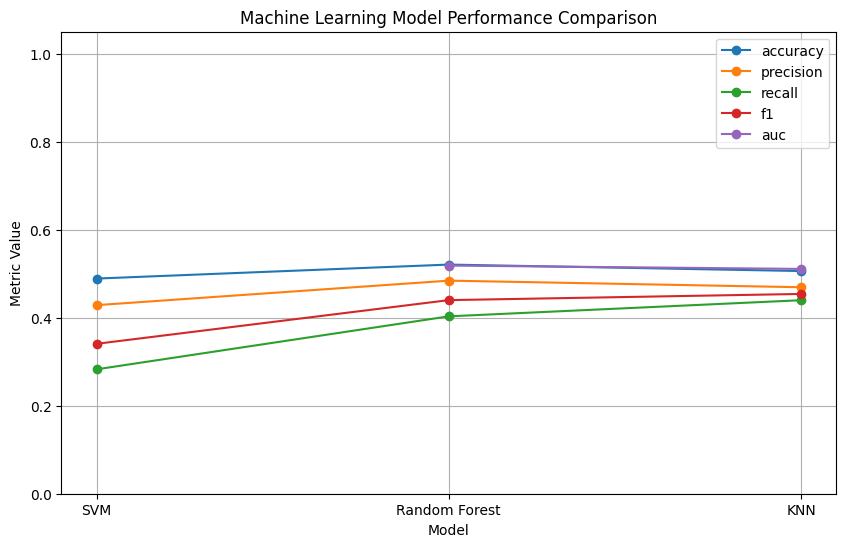

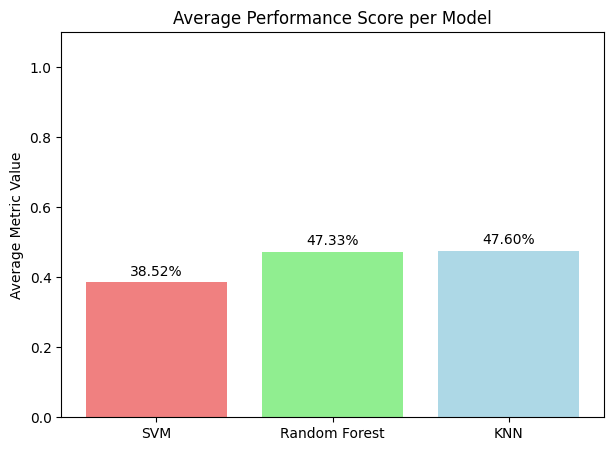

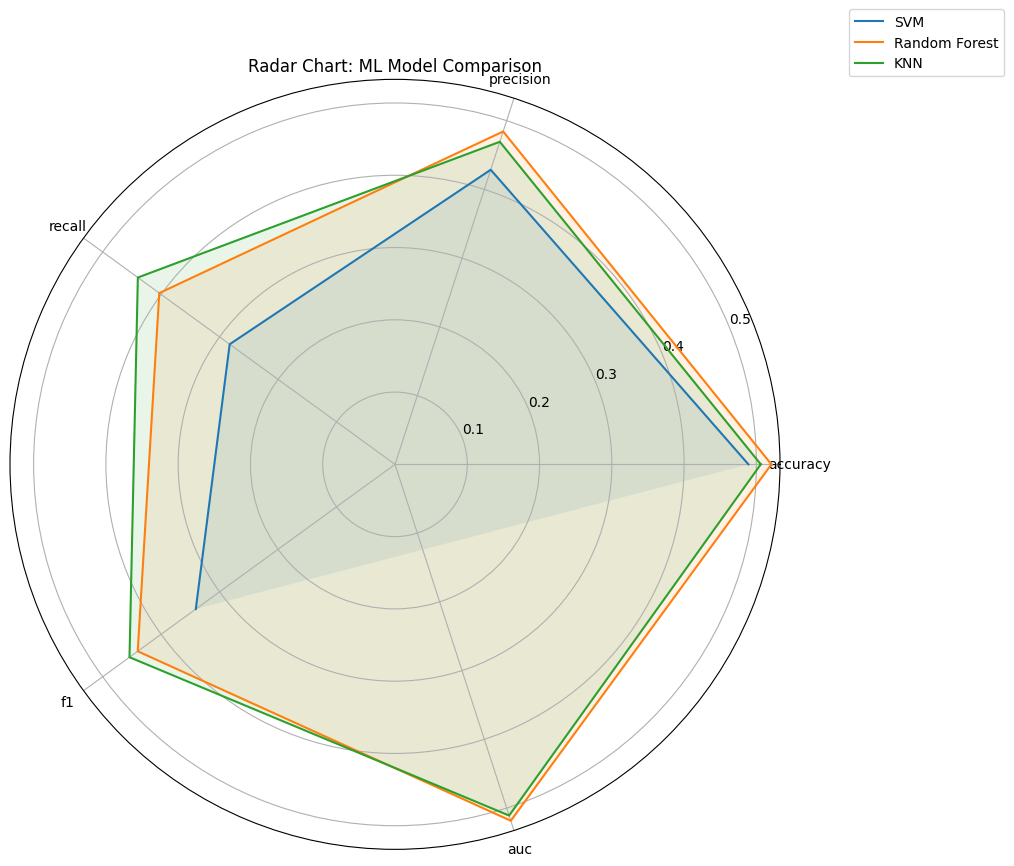

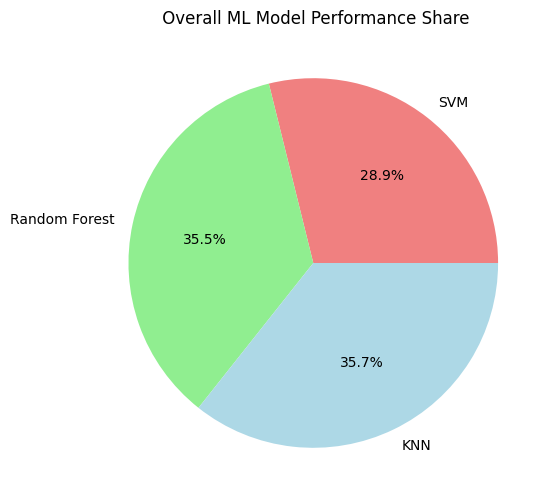

In [12]:
# Line Chart – Metric Comparison

plt.figure(figsize=(10,6))
for metric in results_df.columns:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Metric Value")
plt.xlabel("Model")
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()


# Bar Chart – Average Performance per Model

avg_scores = results_df.mean(axis=1)
plt.figure(figsize=(7,5))
bars = plt.bar(results_df.index, avg_scores, color=['lightcoral','lightgreen','lightblue'])
plt.title("Average Performance Score per Model")
plt.ylabel("Average Metric Value")

for bar, score in zip(bars, avg_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{score*100:.2f}%", ha='center', va='bottom')

plt.ylim(0,1.1)
plt.show()


#  Radar Chart – Metric Profile per Model

from math import pi
metrics = list(results_df.columns)
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)
for model in results_df.index:
    values = results_df.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title("Radar Chart: ML Model Comparison")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


# Pie Chart – Overall Performance Share

total_perf = avg_scores / avg_scores.sum()
plt.figure(figsize=(6,6))
plt.pie(total_perf, labels=avg_scores.index, autopct='%1.1f%%', colors=['lightcoral','lightgreen','lightblue'])
plt.title(" Overall ML Model Performance Share")
plt.show()


In [13]:
# Final Conclusion Report

best_model = avg_scores.idxmax()
print("FINAL COMPARISON REPORT")
print("──────────────────────────────")
for model in results_df.index:
    print(f"{model}: Accuracy={results_df.loc[model,'accuracy']:.3f}, Precision={results_df.loc[model,'precision']:.3f}, Recall={results_df.loc[model,'recall']:.3f}, F1={results_df.loc[model,'f1']:.3f}, AUC={results_df.loc[model,'auc']:.3f}")
print(f"\n Best Performing Model: {best_model}")

FINAL COMPARISON REPORT
──────────────────────────────
SVM: Accuracy=0.489, Precision=0.429, Recall=0.283, F1=0.341, AUC=nan
Random Forest: Accuracy=0.521, Precision=0.484, Recall=0.403, F1=0.440, AUC=0.519
KNN: Accuracy=0.506, Precision=0.469, Recall=0.440, F1=0.454, AUC=0.511

 Best Performing Model: KNN
